In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [ ]:

train_path = "D:\\DS Assignment\\XGBM & LGBM\\XGBM & LGBM\\Titanic_train.csv"
test_path  = "D:\\DS Assignment\\XGBM & LGBM\\XGBM & LGBM\\Titanic_test.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

df_train.shape, df_test.shape, df_train.columns.tolist()


((891, 12),
 (418, 11),
 ['PassengerId',
  'Survived',
  'Pclass',
  'Name',
  'Sex',
  'Age',
  'SibSp',
  'Parch',
  'Ticket',
  'Fare',
  'Cabin',
  'Embarked'])

In [ ]:
display(df_train.head())
display(df_train.info())
print("\nMissing values in train:\n", df_train.isna().sum())

display(df_test.head())
display(df_test.info())
print("\nMissing values in test:\n", df_test.isna().sum())


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None


Missing values in train:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


None


Missing values in test:
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


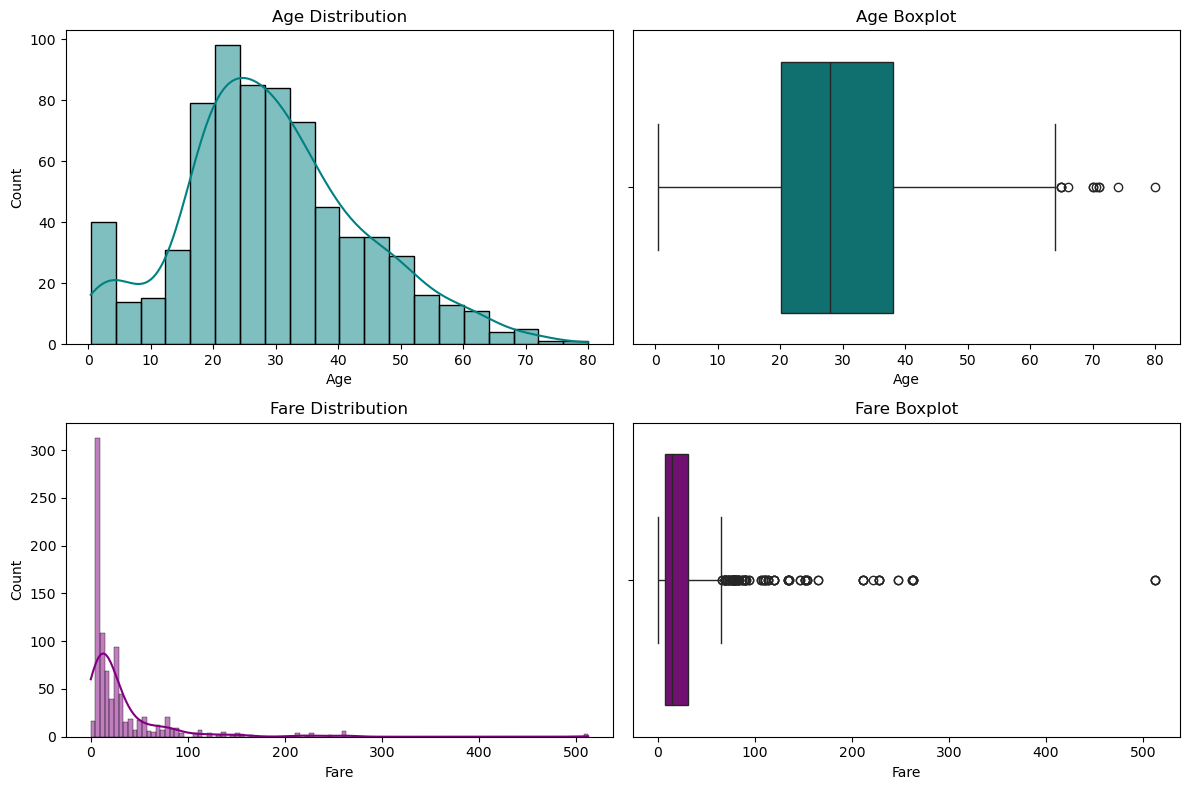

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df_train['Age'], kde=True, ax=axes[0,0], color='teal')
axes[0,0].set_title('Age Distribution')

sns.boxplot(x=df_train['Age'], ax=axes[0,1], color='teal')
axes[0,1].set_title('Age Boxplot')

sns.histplot(df_train['Fare'], kde=True, ax=axes[1,0], color='purple')
axes[1,0].set_title('Fare Distribution')

sns.boxplot(x=df_train['Fare'], ax=axes[1,1], color='purple')
axes[1,1].set_title('Fare Boxplot')

plt.tight_layout()
plt.show()


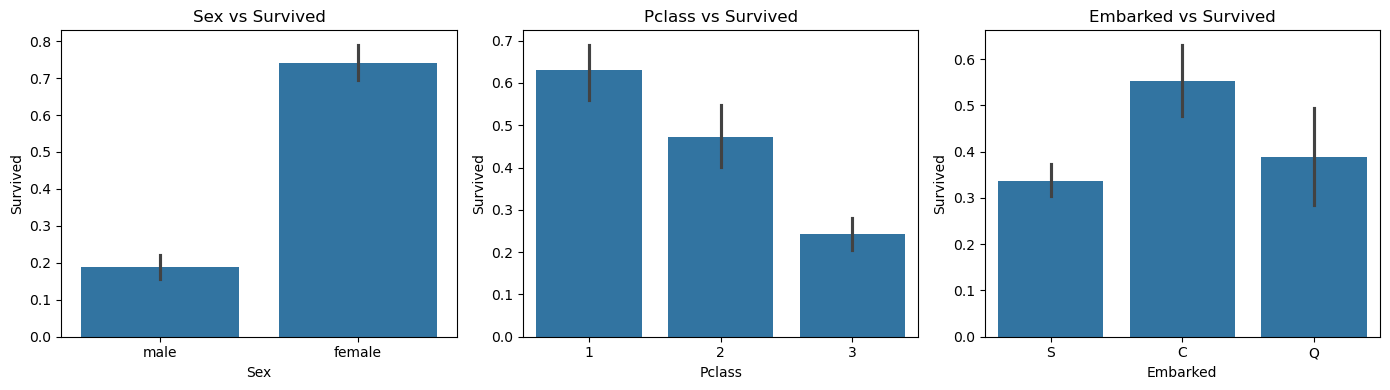

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.barplot(data=df_train, x='Sex', y='Survived', ax=axes[0])
axes[0].set_title('Sex vs Survived')

sns.barplot(data=df_train, x='Pclass', y='Survived', ax=axes[1])
axes[1].set_title('Pclass vs Survived')

sns.barplot(data=df_train, x='Embarked', y='Survived', ax=axes[2])
axes[2].set_title('Embarked vs Survived')

plt.tight_layout()
plt.show()


In [ ]:

import re

def extract_title(name):
    m = re.search(r",\s*([^\.]+)\.", name)
    return m.group(1).strip() if m else "None"

def simplify_title(t):
    rare = {'Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'}
    tmap = {'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'}
    t = tmap.get(t, t)
    return 'Rare' if t in rare else t

def cabin_deck(cabin):
    if pd.isna(cabin) or cabin=='':
        return 'Unknown'
    return str(cabin)[0]

def add_features(df):
    tmp = df.copy()
    tmp['Title'] = tmp['Name'].apply(extract_title).apply(simplify_title)
    tmp['FamilySize'] = tmp['SibSp'] + tmp['Parch'] + 1
    tmp['IsAlone'] = (tmp['FamilySize'] == 1).astype(int)
    tmp['CabinDeck'] = tmp['Cabin'].apply(cabin_deck)
    return tmp

def impute_contextual(train_df, test_df):
    
    full = pd.concat([train_df, test_df], axis=0, ignore_index=True)
    
    embarked_mode = full['Embarked'].mode(dropna=True)[0]
    full['Embarked'] = full['Embarked'].fillna(embarked_mode)
    
    full['Fare'] = full.groupby(['Pclass','Embarked'])['Fare'].transform(
        lambda s: s.fillna(s.median())
    )
    
    full['Age'] = full.groupby(['Title','Pclass','Sex'])['Age'].transform(
        lambda s: s.fillna(s.median())
    )
    
    full['Age'] = full['Age'].fillna(full['Age'].median())
    full['Fare'] = full['Fare'].fillna(full['Fare'].median())
    
    train_fixed = full.iloc[:len(train_df)].copy()
    test_fixed  = full.iloc[len(train_df):].copy()
    return train_fixed, test_fixed


In [ ]:
df_train_fe = add_features(df_train)
df_test_fe  = add_features(df_test)

df_train_fe, df_test_fe = impute_contextual(df_train_fe, df_test_fe)

target = 'Survived'
drop_cols = ['Survived']  # in train only
X = df_train_fe.drop(columns=drop_cols)
y = df_train_fe[target]

X_test_final = df_test_fe.copy()


In [ ]:
categorical_cols = ['Sex','Embarked','Title','CabinDeck','Pclass','IsAlone']
numeric_cols = ['Age','Fare','SibSp','Parch','FamilySize','PassengerId'] 

preprocess = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])


In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train.shape, X_valid.shape


((712, 15), (179, 15))

In [ ]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

pipe_lgbm_base = Pipeline([
    ('prep', preprocess),
    ('clf', LGBMClassifier(random_state=RANDOM_STATE))
])

pipe_xgb_base = Pipeline([
    ('prep', preprocess),
    ('clf', XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False
    ))
])

cv_lgbm = cross_validate(pipe_lgbm_base, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
cv_xgb  = cross_validate(pipe_xgb_base,  X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

def summarize_cv(cvres, name):
    print(f"\n{name} CV means:")
    for k in scoring.keys():
        print(f"{k}: {cvres['test_'+k].mean():.4f} ± {cvres['test_'+k].std():.4f}")

summarize_cv(cv_lgbm, "LGBM (baseline)")
summarize_cv(cv_xgb,  "XGB  (baseline)")



LGBM (baseline) CV means:
accuracy: 0.7922 ± 0.0181
precision: 0.7506 ± 0.0311
recall: 0.6888 ± 0.0371
f1: 0.7175 ± 0.0235
roc_auc: 0.8685 ± 0.0109

XGB  (baseline) CV means:
accuracy: 0.8020 ± 0.0218
precision: 0.7608 ± 0.0422
recall: 0.7108 ± 0.0541
f1: 0.7331 ± 0.0300
roc_auc: 0.8576 ± 0.0120


In [ ]:
from scipy.stats import randint, uniform

lgbm_param_dist = {
    'clf__num_leaves': randint(15, 63),
    'clf__max_depth': randint(3, 10),
    'clf__learning_rate': uniform(0.01, 0.2),
    'clf__n_estimators': randint(150, 600),
    'clf__min_child_samples': randint(5, 50),
    'clf__subsample': uniform(0.6, 0.4),
    'clf__colsample_bytree': uniform(0.6, 0.4)
}

pipe_lgbm = Pipeline([
    ('prep', preprocess),
    ('clf', LGBMClassifier(random_state=RANDOM_STATE))
])

rs_lgbm = RandomizedSearchCV(
    pipe_lgbm,
    param_distributions=lgbm_param_dist,
    n_iter=40,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

rs_lgbm.fit(X_train, y_train)
best_lgbm = rs_lgbm.best_estimator_
rs_lgbm.best_params_, rs_lgbm.best_score_


[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000531 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 479
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

({'clf__colsample_bytree': np.float64(0.8446612641953124),
  'clf__learning_rate': np.float64(0.011413261043943482),
  'clf__max_depth': 3,
  'clf__min_child_samples': 31,
  'clf__n_estimators': 208,
  'clf__num_leaves': 56,
  'clf__subsample': np.float64(0.6186662652854461)},
 np.float64(0.7612400020046903))

In [ ]:
xgb_param_dist = {
    'clf__max_depth': randint(3, 10),
    'clf__min_child_weight': randint(1, 8),
    'clf__learning_rate': uniform(0.01, 0.2),
    'clf__n_estimators': randint(150, 600),
    'clf__subsample': uniform(0.6, 0.4),
    'clf__colsample_bytree': uniform(0.6, 0.4),
    'clf__gamma': uniform(0.0, 5.0)
}

pipe_xgb = Pipeline([
    ('prep', preprocess),
    ('clf', XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False
    ))
])

rs_xgb = RandomizedSearchCV(
    pipe_xgb,
    param_distributions=xgb_param_dist,
    n_iter=40,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

rs_xgb.fit(X_train, y_train)
best_xgb = rs_xgb.best_estimator_
rs_xgb.best_params_, rs_xgb.best_score_


({'clf__colsample_bytree': np.float64(0.7060809470726902),
  'clf__gamma': np.float64(1.2199482168954179),
  'clf__learning_rate': np.float64(0.20460211095048914),
  'clf__max_depth': 7,
  'clf__min_child_weight': 3,
  'clf__n_estimators': 587,
  'clf__subsample': np.float64(0.9624395150874216)},
 np.float64(0.7588999992661576))


LightGBM (tuned) Valid Scores:
Accuracy: 0.8212 | Precision: 0.8364 | Recall: 0.6667 | F1: 0.7419 | ROC-AUC: 0.8415


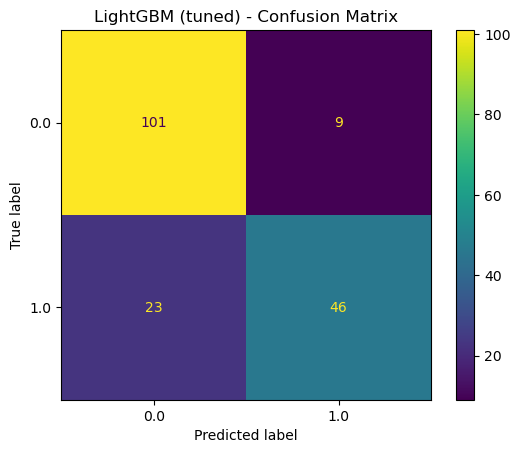


Classification Report:
               precision    recall  f1-score   support

         0.0       0.81      0.92      0.86       110
         1.0       0.84      0.67      0.74        69

    accuracy                           0.82       179
   macro avg       0.83      0.79      0.80       179
weighted avg       0.82      0.82      0.82       179


XGBoost  (tuned) Valid Scores:
Accuracy: 0.8045 | Precision: 0.7742 | Recall: 0.6957 | F1: 0.7328 | ROC-AUC: 0.8560


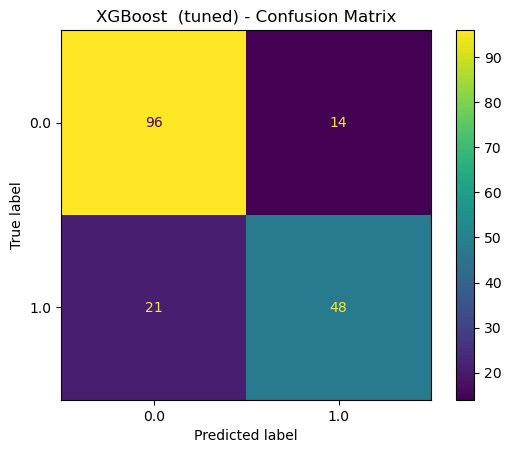


Classification Report:
               precision    recall  f1-score   support

         0.0       0.82      0.87      0.85       110
         1.0       0.77      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



({'accuracy': 0.8212290502793296,
  'precision': 0.8363636363636363,
  'recall': 0.6666666666666666,
  'f1': 0.7419354838709677,
  'roc_auc': np.float64(0.841501976284585)},
 {'accuracy': 0.8044692737430168,
  'precision': 0.7741935483870968,
  'recall': 0.6956521739130435,
  'f1': 0.732824427480916,
  'roc_auc': np.float64(0.8559947299077735)})

In [ ]:
def evaluate_on_valid(model, name):
    pred = model.predict(X_valid)
    proba = model.predict_proba(X_valid)[:,1]
    acc  = accuracy_score(y_valid, pred)
    prec = precision_score(y_valid, pred)
    rec  = recall_score(y_valid, pred)
    f1   = f1_score(y_valid, pred)
    auc  = roc_auc_score(y_valid, proba)
    print(f"\n{name} Valid Scores:")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | ROC-AUC: {auc:.4f}")
    ConfusionMatrixDisplay.from_predictions(y_valid, pred)
    plt.title(f"{name} - Confusion Matrix")
    plt.show()
    print("\nClassification Report:\n", classification_report(y_valid, pred))
    return {'accuracy':acc,'precision':prec,'recall':rec,'f1':f1,'roc_auc':auc}

metrics_lgbm = evaluate_on_valid(best_lgbm, "LightGBM (tuned)")
metrics_xgb  = evaluate_on_valid(best_xgb,  "XGBoost  (tuned)")
metrics_lgbm, metrics_xgb


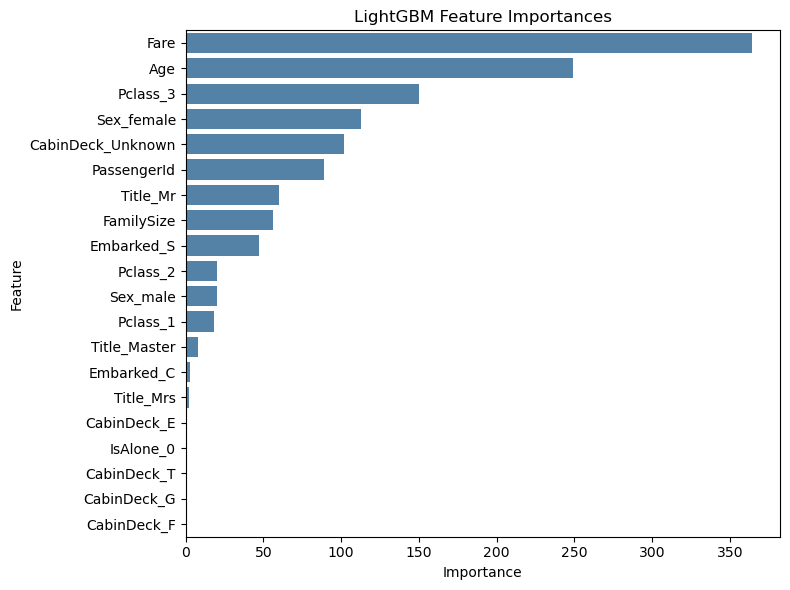

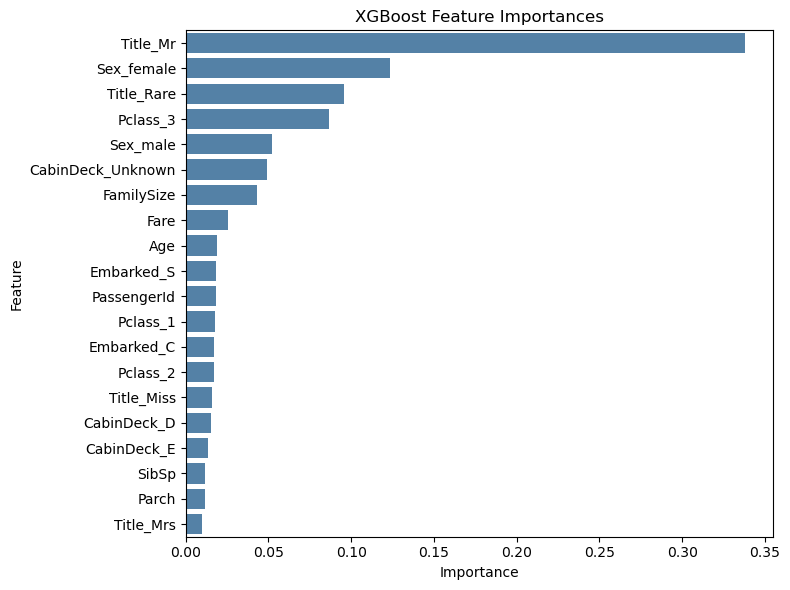

In [ ]:

def get_feature_names(preprocess, numeric_cols, categorical_cols):
    
    num_names = numeric_cols
   
    ohe = preprocess.named_transformers_['cat']
    cat_names = ohe.get_feature_names_out(categorical_cols).tolist()
    return num_names + cat_names

def plot_importances(pipeline, title, top_n=20):
    clf = pipeline.named_steps['clf']
    feat_names = get_feature_names(pipeline.named_steps['prep'], numeric_cols, categorical_cols)
    importances = None
    if hasattr(clf, 'feature_importances_'):
        importances = clf.feature_importances_
    elif hasattr(clf, 'get_booster'):
        importances = clf.get_booster().get_fscore()
    else:
        print("No feature importances available")
        return
    if isinstance(importances, dict):
        
        keys = [int(k.replace('f','')) for k in importances.keys()]
        vals = np.array(list(importances.values()))
        
        mapped = pd.Series(0, index=range(len(feat_names)), dtype=float)
        for k,v in zip(keys, vals):
            if k < len(feat_names):
                mapped.iloc[k] = v
        s = pd.Series(mapped.values, index=feat_names)
    else:
        s = pd.Series(importances, index=feat_names)
    s = s.sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(8, max(4, top_n*0.3)))
    sns.barplot(x=s.values, y=s.index, orient='h', color='steelblue')
    plt.title(title)
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

plot_importances(best_lgbm, "LightGBM Feature Importances", top_n=20)
plot_importances(best_xgb,  "XGBoost Feature Importances",  top_n=20)


In [ ]:
pick = 'lgbm' if metrics_lgbm['f1'] >= metrics_xgb['f1'] else 'xgb'
final_model = best_lgbm if pick=='lgbm' else best_xgb
print("Chosen final model:", "LightGBM" if pick=='lgbm' else "XGBoost")

final_model.fit(X, y)
test_pred = final_model.predict(X_test_final)

submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': test_pred.astype(int)
})
submission.to_csv('submission.csv', index=False)
submission.head()


Chosen final model: LightGBM
[LightGBM] [Info] Number of positive: 342, number of negative: 549
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001431 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 516
[LightGBM] [Info] Number of data points in the train set: 891, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383838 -> initscore=-0.473288
[LightGBM] [Info] Start training from score -0.473288
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
